<a href="https://colab.research.google.com/github/JihoonJung2/undergrad-research-practicum/blob/main/day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Subset
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# ResNet-50은 원래 ImageNet(224x224)으로 학습됐기 때문에, 입력 이미지를 224x224로 맞춰야 함
# CIFAR-10은 32x32라서 Resize로 강제 확대
transform = transforms.Compose([
    transforms.Resize((224, 224)),      # CIFAR-10(32x32) → ResNet 입력 크기(224x224)로 확대
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet으로 사전학습된 모델이라, 정규화 값도 ImageNet 기준값 사용
                          std=[0.229, 0.224, 0.225]),
])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
full_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# "작은 데이터셋"이라는 과제 조건에 맞춰 일부만 샘플링 (학습 2000장, 테스트 500장)
train_indices = np.random.choice(len(full_trainset), 2000, replace=False)
test_indices = np.random.choice(len(full_testset), 500, replace=False)

trainset = Subset(full_trainset, train_indices)
testset = Subset(full_testset, test_indices)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f"학습 데이터: {len(trainset)}장, 테스트 데이터: {len(testset)}장")

cuda


100%|██████████| 170M/170M [45:02<00:00, 63.1kB/s]


학습 데이터: 2000장, 테스트 데이터: 500장


In [4]:
# 사전학습된 ResNet-50 불러오기 (ImageNet으로 이미 학습된 가중치 포함)
weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)

# 1단계: 백본(feature extractor) 전체를 freeze — 기존에 학습된 가중치를 건드리지 않음
for param in model.parameters():
    param.requires_grad = False   # gradient 계산 안 함 → 학습 시 업데이트 안 됨

# 2단계: 마지막 분류층(fc)만 우리 클래스 수(10개)에 맞게 새로 교체
# 새로 교체된 레이어는 기본적으로 requires_grad=True라서, 이 레이어만 학습됨
num_features = model.fc.in_features   # ResNet-50의 원래 fc 레이어 입력 크기 (2048)
model.fc = nn.Linear(num_features, 10)   # ImageNet 1000개 클래스용 → CIFAR-10 10개 클래스용으로 교체

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# freeze했기 때문에, 실제로 학습되는 건 새로 교체한 model.fc의 파라미터뿐
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.3MB/s]


In [5]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


In [6]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def evaluate_with_metrics(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []   # 전체 예측값/정답값을 모아둘 리스트

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())    # GPU tensor → CPU numpy로 변환해서 저장
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    # precision, recall, f1을 클래스별로 계산 후 평균(macro: 클래스마다 동일 가중치)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, precision, recall, f1, cm

In [7]:
EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion)
    val_loss, val_acc, precision, recall, f1, cm = evaluate_with_metrics(model, testloader, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.3f} acc {train_acc:.3f} | val_loss {val_loss:.3f} acc {val_acc:.3f}")

print("\n=== 최종 평가 지표 ===")
print(f"Accuracy:  {val_acc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

Epoch 1/10 | train_loss 1.746 acc 0.470 | val_loss 1.336 acc 0.664
Epoch 2/10 | train_loss 1.139 acc 0.692 | val_loss 1.067 acc 0.690
Epoch 3/10 | train_loss 0.921 acc 0.760 | val_loss 0.989 acc 0.700
Epoch 4/10 | train_loss 0.813 acc 0.774 | val_loss 0.942 acc 0.712
Epoch 5/10 | train_loss 0.722 acc 0.812 | val_loss 0.869 acc 0.724
Epoch 6/10 | train_loss 0.662 acc 0.814 | val_loss 0.870 acc 0.714
Epoch 7/10 | train_loss 0.621 acc 0.828 | val_loss 0.839 acc 0.736
Epoch 8/10 | train_loss 0.558 acc 0.860 | val_loss 0.833 acc 0.732
Epoch 9/10 | train_loss 0.533 acc 0.847 | val_loss 0.827 acc 0.728
Epoch 10/10 | train_loss 0.489 acc 0.876 | val_loss 0.814 acc 0.714

=== 최종 평가 지표 ===
Accuracy:  0.714
Precision: 0.717
Recall:    0.709
F1 Score:  0.706


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

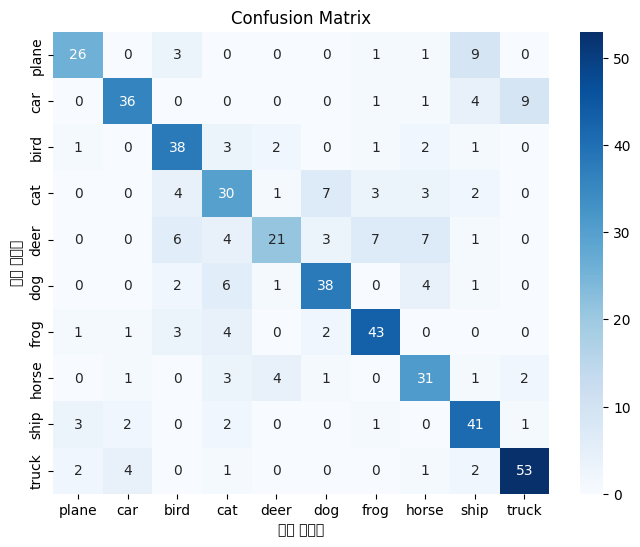

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('예측 클래스')
plt.ylabel('실제 클래스')
plt.title('Confusion Matrix')
plt.show()